# 10 · Cookbook — the Si→SiN escalator on the *free* engine

A **cookbook** of reference devices with known-good S-parameters. The first
entry is the **Si→SiN escalator**: a silicon waveguide that hands its light
*up* to a silicon-nitride waveguide sitting 0.3 µm above it — a **vertical,
adiabatic mode transfer** used to route between the Si and SiN layers of a
photonic stack.

It is a **multi-layer** device: **two** patterned device layers (Si at
z 0–0.22 µm, SiN at z 0.3–0.7 µm), not one. The geometry is simple enough that
the **free** engine ([beamz](https://github.com/beamzorg/beamz), Apache-2.0 JAX
FDTD, CPU/GPU) runs it end-to-end, and reproduces the same device that the
commercial tidy3d and Lumerical engines recorded, to within ~0.1 dB on the
through path.

Same three inputs → one output, exactly as everywhere else:
a `Component` + a `Technology` + a `SimulationSpec` → one `SMatrix`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from gds_fdtd.lyprocessor import load_cell
from gds_fdtd.plotting import plot_component, plot_permittivity, plot_smatrix, plot_tech_stack
from gds_fdtd.simprocessor import load_component_from_tech
from gds_fdtd.smatrix import SMatrix
from gds_fdtd.spec import SimulationSpec
from gds_fdtd.technology import Technology


def _find(rel: str) -> Path:
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / rel).exists():
            return base / rel
    raise FileNotFoundError(rel)


HERE = _find("examples/10_cookbook")
# the SHARED technology — it already defines the Si + SiN + SiO₂ vertical stack
# (Si core [1,0] @ z 0–0.22 µm, SiN core [4,0] @ z 0.3–0.7 µm). No escalator-only
# tech needed; the GDS uses those same layers.
tech = Technology.from_yaml(_find("examples/tech.yaml"))

## 1 · The technology — a two-core vertical stack

The escalator uses the **shared** `examples/tech.yaml` — no device-specific
technology needed. It already defines **two** device layers: `Si` (n≈3.48) is
the lower core; `SiN` (n≈2.0) is the upper core, 0.3 µm above it; both are clad
in `SiO₂` (n≈1.44). Each material carries a neutral `nk` so the free beamz engine
can resolve indices offline, plus per-engine hints (`tidy3d`, `lumerical`) for
the commercial solvers — **one technology file, every engine**.

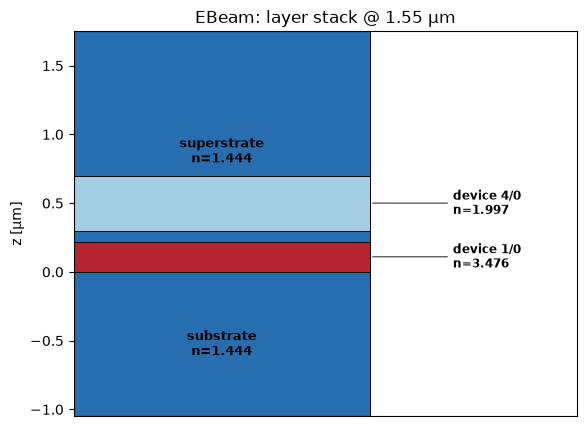

In [2]:
plot_tech_stack(tech, wavelength_um=1.55)
plt.show()

## 2 · The device — two patterned cores

We load `si_sin_escalator.gds` (KLayout/SiEPIC) and pair it with the technology
to build a `Component`. Ports are auto-detected from the pin layer: **opt1** on
the Si layer (west, z≈0.11 µm) and **opt2** on the SiN layer (east, z≈0.5 µm).
Passing a `SimulationSpec` also sketches the **FDTD region** (device bounds + a
buffer) and the **port-extension stubs** that carry each port out through the
PML. It's a schematic of the setup — the exact margins are engine-specific
(beamz uses its own fixed guard band); the full run spec is defined in §3.

20:43:33 PDT WARNING: Using canonical configuration directory at                
             '/home/mustafa/.config/tidy3d'. Found legacy directory at          
             '~/.tidy3d', which will be ignored. Remove it manually or run      
             'tidy3d config migrate --delete-legacy' to clean up.               

ports:
  opt1: center=[0.0, 0.0, 0.11] µm, dir=180°
  opt2: center=[18.0, 0.0, 0.5] µm, dir=0°


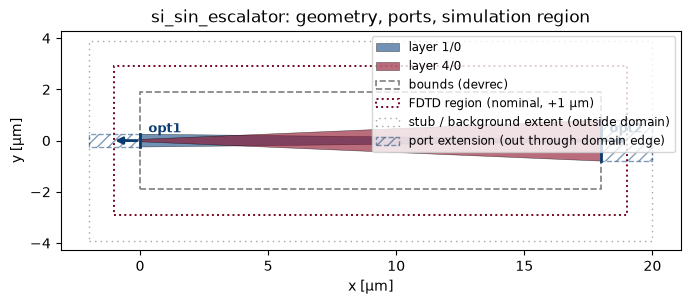

In [3]:
cell, _layout = load_cell(str(HERE / "si_sin_escalator.gds"))
component = load_component_from_tech(cell=cell, tech=tech)
component.name = "si_sin_escalator"
print("ports:")
for p in component.ports:
    print(f"  {p.name}: center={[round(float(c), 3) for c in p.center]} µm, dir={p.direction}°")

plot_component(component, spec=SimulationSpec())
plt.show()

The top-down view collapses the stack. The refractive-index cross-section
**along** the waveguide (the x–z plane the solver actually rasterizes) shows the
two cores directly: the **Si** core enters from the left and tapers away, while
the **SiN** core rises above it and carries the light out to the right — the
"escalator."

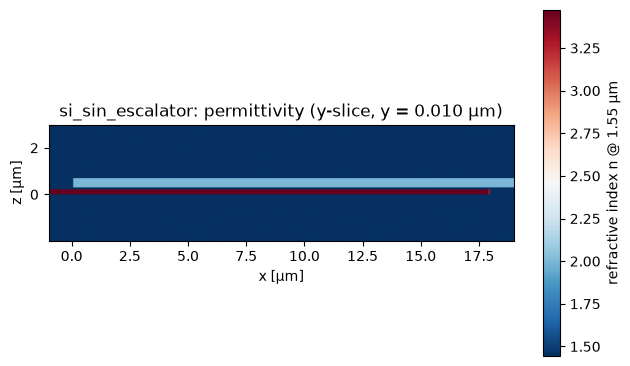

In [4]:
plot_permittivity(component, axis="y", position=0.0, wavelength_um=1.55)
plt.show()

### The two modes the escalator connects

What actually transfers is a **guided mode**: the light enters as the Si
strip's TE0 and must leave as the SiN strip's TE0. Both are solved offline
below (tidy3d's free local mode solver). The SiN mode is *larger and less
confined* (lower index contrast), and the taper adiabatically morphs one into
the other.

20:43:39 PDT WARNING: Use the remote mode solver with subpixel averaging for    
             better accuracy through 'tidy3d.web.run(...)' or the deprecated    
             'tidy3d.plugins.mode.web.run(...)'. Alternatively, you can install 
             the package 'tidy3d-extras' using 'pip install "tidy3d"' and set   
             'config.simulation.use_local_subpixel=True'.                       

             WARNING: Permittivity spatial data array does not fully cover the  
             requested region.                                                  

20:43:40 PDT WARNING: Permittivity spatial data array does not fully cover the  
             requested region.                                                  

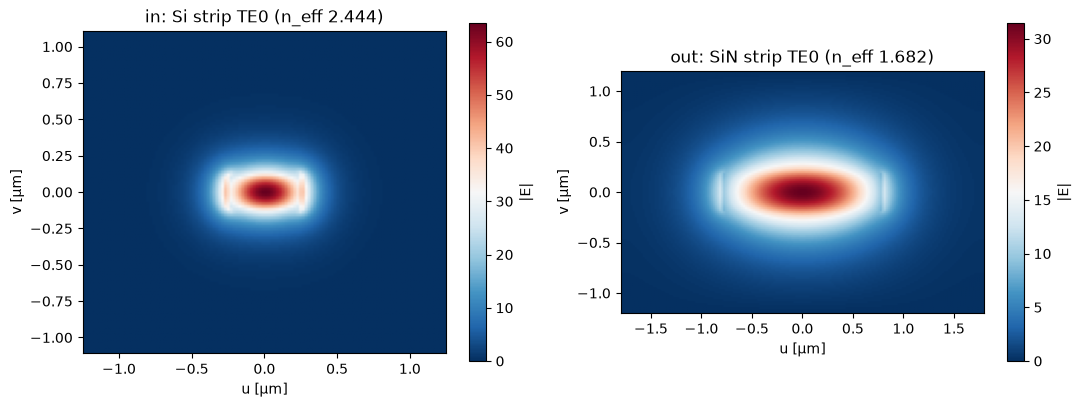

In [5]:
from gds_fdtd.grid import resolve_index  # noqa: E402
from gds_fdtd.modes import waveguide_mode  # noqa: E402
from gds_fdtd.plotting import plot_mode  # noqa: E402

n_clad = resolve_index(tech.superstrate.material, 1.55).real
ports_by_z = sorted(component.ports, key=lambda p: p.center[2])
si_port, sin_port = ports_by_z[0], ports_by_z[-1]  # Si core low, SiN core high
si_layer = min(tech.device, key=lambda d: d.z_base)
sin_layer = max(tech.device, key=lambda d: d.z_base)
si_mode = waveguide_mode(
    si_port.width, abs(si_layer.z_span), resolve_index(si_layer.material, 1.55).real, n_clad, 1.55
)[0]
sin_mode = waveguide_mode(
    sin_port.width,
    abs(sin_layer.z_span),
    resolve_index(sin_layer.material, 1.55).real,
    n_clad,
    1.55,
)[0]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
plot_mode(si_mode, ax=ax[0])
ax[0].set_title(f"in: Si strip TE0 (n_eff {si_mode.n_eff.real:.3f})")
plot_mode(sin_mode, ax=ax[1])
ax[1].set_title(f"out: SiN strip TE0 (n_eff {sin_mode.n_eff.real:.3f})")
fig.tight_layout()
plt.show()

## 3 · Set up and run — on the free engine

`validate()` / `build()` / `estimate()` are **offline and free** — preview the
whole job before spending anything. beamz then runs one FDTD per port
excitation (two here) on the CPU. (For repeat runs, `run_cached(cache_dir)`
hashes the job and reloads the stored `SMatrix` — see
`06_convergence_and_caching`.)

In [6]:
from gds_fdtd.solvers import get_solver  # noqa: E402

spec = SimulationSpec(
    wavelength_start=1.5, wavelength_end=1.6, wavelength_points=11, mesh=6, z_min=-1.0, z_max=1.11
)
solver = get_solver("beamz")(component, technology=tech, spec=spec)

print("validate():", solver.validate() or "OK — no problems")
print("build():   ", solver.build().summary)
print("estimate():", solver.estimate())

validate(): OK — no problems
● Info: Auto-selecting 3D meshing for 3D design
● Rasterizing 3D structures...
● Rasterizing 3D structures... done (4/4)
● Info: 3D raster timing: setup=0.02s, structures=0.04s, pml=0.00s, total=0.07s
● Info: 3D raster kernels: fast_enabled=True, fast_rect=0, fast_poly=3, fallback=0
● Done: Created 3D mesh: 322 × 87 × 76 cells


● Info: Raster cache saved: 6a20766e0b60e7cf645b89503dd6ac648a2608e261b022101d06206bec9fb602.npz | save=0.34s
● Info: Rasterize wall-time: 0.07s | total=0.42s
build():    {'n_ports': 2, 'grid_shape': (76, 87, 322), 'dx_nm': 74.31914077483697, 'n_core': 3.476, 'n_clad': 1.444, 'n_simulations': 2}
estimate(): ResourceEstimate(grid_cells=2129064, memory_gb=0.102195072, n_simulations=2, cost_hint='free local compute (JAX; CPU works, GPU if available)')


In [7]:
smatrix = solver.run()  # one FDTD per port; ~1-2 min on a CPU
print("S-matrix:", smatrix.port_names, "| modes:", smatrix.n_modes, "| freqs:", smatrix.f.size)

S-matrix: ['opt1', 'opt2'] | modes: 1 | freqs: 11


## 4 · S-parameters

The through path `opt1→opt2` should be near **0 dB** (an efficient adiabatic
transfer) with deep back-reflection at `opt1`.

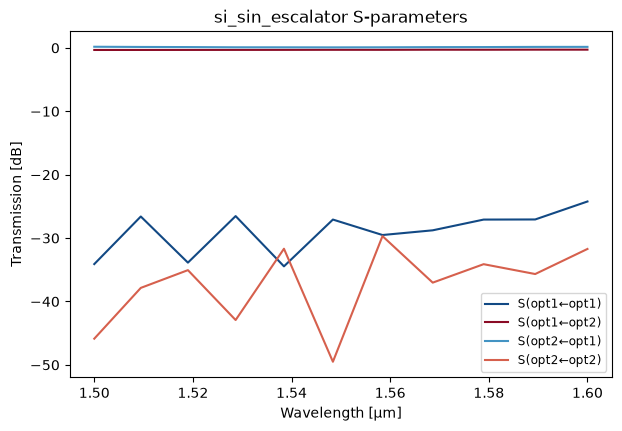

beamz through opt1→opt2: +0.18 dB peak
beamz through opt2→opt1: -0.28 dB peak  (≈ opt1→opt2: near-reciprocal)
beamz reflection opt1:   -24.23 dB peak
passive: True


In [8]:
plot_smatrix(smatrix, kind="db")
plt.show()


def thru(sm: SMatrix) -> np.ndarray:
    return sm.magnitude_db(out=sm.port_names[1], in_=sm.port_names[0])


def refl(sm: SMatrix) -> np.ndarray:
    return sm.magnitude_db(out=sm.port_names[0], in_=sm.port_names[0])


back = smatrix.magnitude_db(out=smatrix.port_names[0], in_=smatrix.port_names[1])
print(f"beamz through opt1→opt2: {float(np.nanmax(thru(smatrix))):+.2f} dB peak")
print(
    f"beamz through opt2→opt1: {float(np.nanmax(back)):+.2f} dB peak  (≈ opt1→opt2: near-reciprocal)"
)
print(f"beamz reflection opt1:   {float(np.nanmax(refl(smatrix))):+.2f} dB peak")
print("passive:", smatrix.is_passive(atol=0.05))

## 5 · The field — light climbing the escalator

The frequency-domain `|E|²` profile at the Si-core plane: the mode enters on the
Si waveguide (left) and its energy leaves the Si plane as it transfers up into
the SiN core — the vertical hand-off in action.

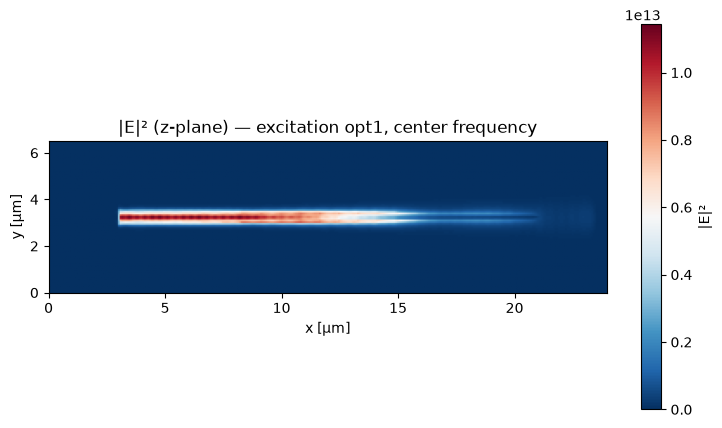

In [9]:
solver.plot_fields(axis="z")
plt.show()

## 6 · Cross-validation — free vs commercial

**beamz is the only engine executed in this notebook.** The tidy3d
and Lumerical curves are **pre-recorded reference results** (`recorded/`, see
`PROVENANCE.md`) from an earlier live validation on those engines for the
*identical* device — they are *not* re-run here (that needs cloud credits / a
license). Overlaying the free beamz result on them: the three engines agree on
the through transfer to within ~0.1–0.2 dB, and all show deep reflection.

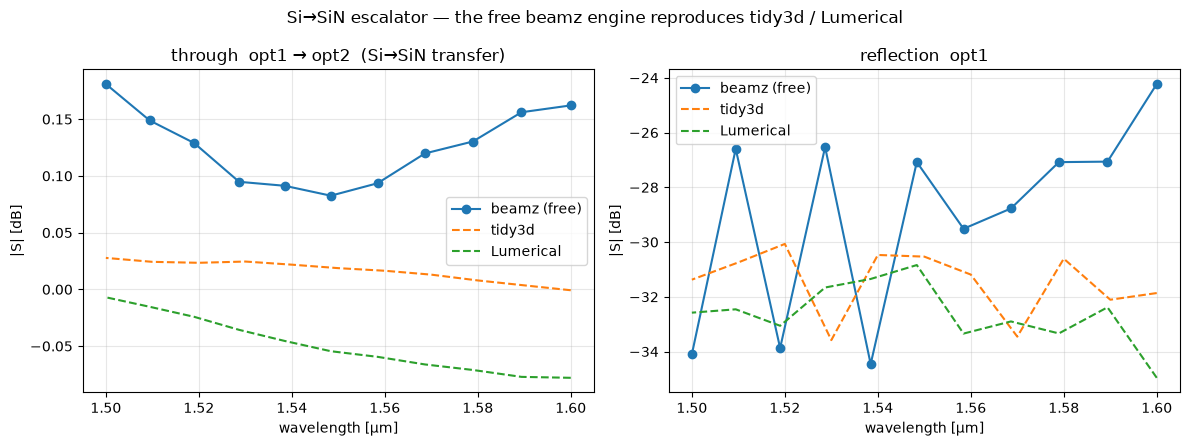

In [10]:
ref_tidy3d = SMatrix.from_npz(str(HERE / "recorded" / "si_sin_escalator_tidy3d.npz"))
ref_lumerical = SMatrix.from_npz(str(HERE / "recorded" / "si_sin_escalator_lumerical.npz"))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for sm, label, style in [
    (smatrix, "beamz (free)", "o-"),
    (ref_tidy3d, "tidy3d", "--"),
    (ref_lumerical, "Lumerical", "--"),
]:
    ax[0].plot(sm.wavelength_um, thru(sm), style, label=label)
    ax[1].plot(sm.wavelength_um, refl(sm), style, label=label)
ax[0].set_title("through  opt1 → opt2  (Si→SiN transfer)")
ax[1].set_title("reflection  opt1")
for a in ax:
    a.set_xlabel("wavelength [µm]")
    a.set_ylabel("|S| [dB]")
    a.grid(alpha=0.3)
    a.legend()
fig.suptitle("Si→SiN escalator — the free beamz engine reproduces tidy3d / Lumerical")
fig.tight_layout()
plt.show()

In [11]:
print(f"{'wavelength':>10} | {'beamz':>8} {'tidy3d':>8} {'lumerical':>10}   (through, dB)")
grid = ref_tidy3d.wavelength_um
for i, wl in enumerate(grid):
    b = float(np.interp(wl, smatrix.wavelength_um[::-1], thru(smatrix)[::-1]))
    print(
        f"{wl:>10.3f} | {b:>8.2f} {float(thru(ref_tidy3d)[i]):>8.2f} {float(thru(ref_lumerical)[i]):>10.2f}"
    )

wavelength |    beamz   tidy3d  lumerical   (through, dB)
     1.600 |     0.16    -0.00      -0.08
     1.590 |     0.16     0.00      -0.08
     1.580 |     0.13     0.01      -0.07
     1.570 |     0.12     0.01      -0.07
     1.560 |     0.10     0.02      -0.06
     1.550 |     0.08     0.02      -0.05
     1.540 |     0.09     0.02      -0.05
     1.530 |     0.09     0.02      -0.04
     1.520 |     0.13     0.02      -0.02
     1.510 |     0.15     0.02      -0.02
     1.500 |     0.18     0.03      -0.01


## Recap & next

- The Si→SiN escalator is a **multi-layer** device (two cores at different z);
  `get_solver("beamz")` builds and runs it on the free engine — no cloud
  account, no license.
- Through transfer ≈ 0 dB with deep reflection, **matching recorded tidy3d and
  Lumerical** to ~0.1–0.2 dB: physics you can trust from a zero-cost solver.
- Same pattern as everywhere: `Component` + `Technology` + `SimulationSpec` →
  `SMatrix`. See **`07_choosing_an_engine`** for the identical-job three-engine
  comparison on a single-layer device, and **`04_reading_results`** for the full
  `SMatrix` analysis surface.